Loading data... please wait, this may take a moment.
✅ Data loaded successfully!
Dataset Dimensions: 246009 rows and 123 columns.

Preview of the data:
   Unnamed: 0  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0           0       0         Cash loans           F            N   
1           1       0         Cash loans           F            N   
2           2       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               N             0          270000.0   1293502.5      35698.5   
1               Y             0          135000.0    312682.5      29686.5   
2               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0                0                0   
1  ...                 0                0                0   
2  ...                 0                0                0   

  AMT_REQ

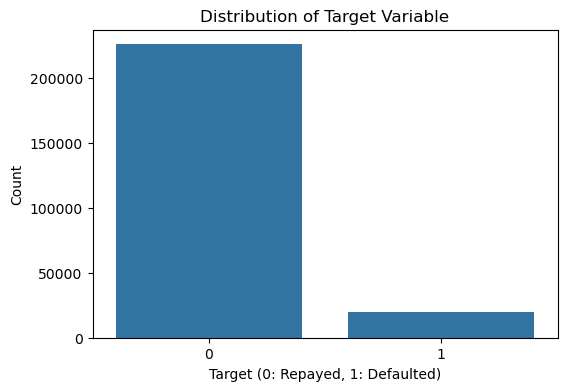

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the data directory path
# Using a raw string (r"") to handle backslashes correctly in Windows paths
DATA_DIR = r"C:\Users\pc\Documents\Downloads\home-credit-default-risk"
FILE_NAME = 'application_train.csv'
file_path = os.path.join(DATA_DIR, FILE_NAME)

def load_and_analyze_target(path):
    """
    Loads the training dataset and performs an initial analysis 
    of the target variable distribution.
    """
    try:
        print("Loading data... please wait, this may take a moment.")
        # Load the dataset
        df_train = pd.read_csv(path)
        print(f"✅ Data loaded successfully!")
        print(f"Dataset Dimensions: {df_train.shape[0]} rows and {df_train.shape[1]} columns.\n")
        
        # Display the first few rows for validation
        print("Preview of the data:")
        print(df_train.head(3))
        print("-" * 50)

        # --- Analyze the Target Variable ---
        # Calculate counts and proportions
        target_counts = df_train['TARGET'].value_counts()
        target_proportions = df_train['TARGET'].value_counts(normalize=True) * 100

        print("Distribution of the Target Variable:")
        if 0 in target_counts:
            print(f"Repaid (0): {target_counts[0]} clients ({target_proportions[0]:.2f}%)")
        if 1 in target_counts:
            print(f"Defaulted (1): {target_counts[1]} clients ({target_proportions[1]:.2f}%)")

        # Visualize the distribution
        plt.figure(figsize=(6, 4))
        sns.countplot(x='TARGET', data=df_train)
        plt.title('Distribution of Target Variable')
        plt.xlabel('Target (0: Repayed, 1: Defaulted)')
        plt.ylabel('Count')
        plt.show()

    except FileNotFoundError:
        print(f"❌ Error: File not found at {path}.")
        print(f"Please ensure '{FILE_NAME}' is located in the specified directory.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

if __name__ == "__main__":
    load_and_analyze_target(file_path)

✅ Data loaded successfully!

📊 Mean Age and Total Income by Repayment Status:
        DAYS_BIRTH_YEARS  AMT_INCOME_TOTAL
TARGET                                    
0              44.217328     169090.610413
1              40.813482     161271.511446


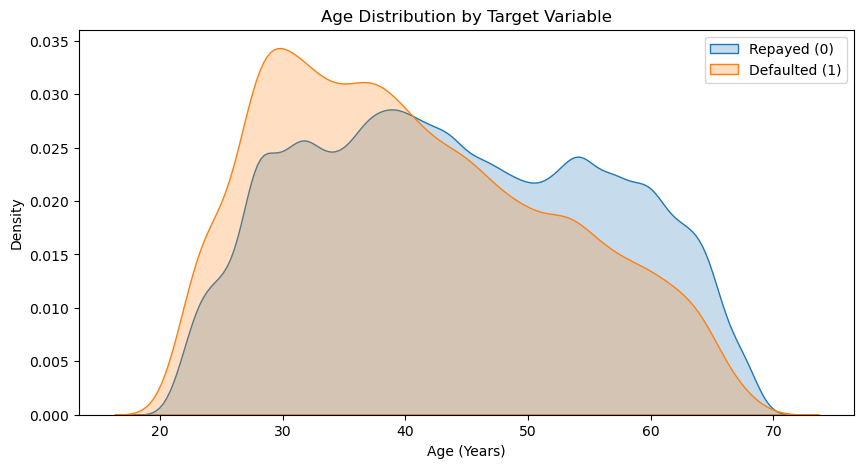


📊 Credit Default Rate (%) by Education Level:
NAME_EDUCATION_TYPE
Lower secondary                  10.96%
Secondary / secondary special     8.93%
Incomplete higher                 8.60%
Higher education                  5.40%
Academic degree                   2.31%
Name: TARGET, dtype: object


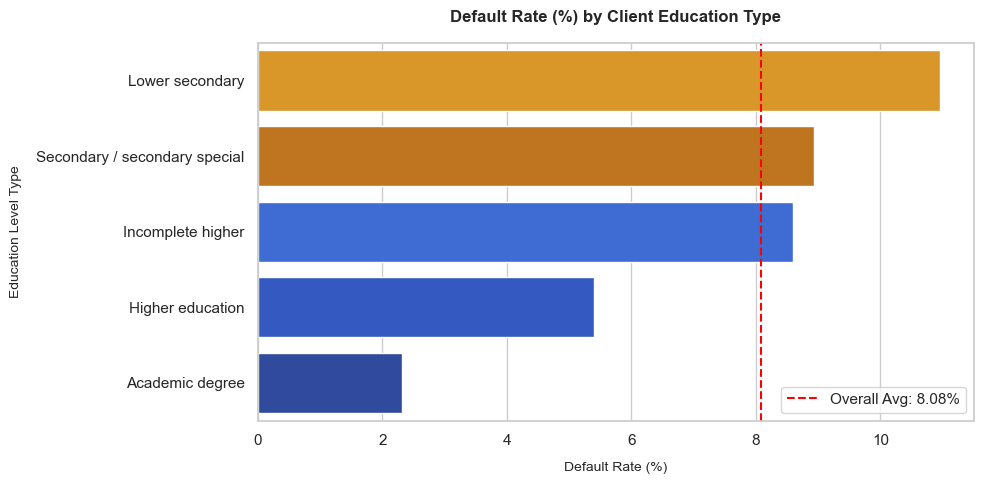

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- 1. Configuration and Data Loading ---
DATA_DIR = r"C:\Users\pc\Documents\Downloads\home-credit-default-risk"
file_path = os.path.join(DATA_DIR, 'application_train.csv')

# Load the dataset
try:
    df_train = pd.read_csv(file_path)
    print("✅ Data loaded successfully!")
except FileNotFoundError:
    print(f"❌ Error: The file was not found at {file_path}")
    exit()

# --- 2. Data Engineering ---
# Convert age from negative days to years for better interpretability
df_train['DAYS_BIRTH_YEARS'] = df_train['DAYS_BIRTH'] / -365

# --- 3. Statistical Analysis ---
# Calculate mean age and income grouped by target status
summary_stats = df_train.groupby('TARGET')[['DAYS_BIRTH_YEARS', 'AMT_INCOME_TOTAL']].mean()
print("\n📊 Mean Age and Total Income by Repayment Status:")
print(summary_stats)

# --- 4. Visualization: Age Distribution ---
plt.figure(figsize=(10, 5))
sns.kdeplot(df_train[df_train['TARGET'] == 0]['DAYS_BIRTH_YEARS'], label='Repayed (0)', fill=True)
sns.kdeplot(df_train[df_train['TARGET'] == 1]['DAYS_BIRTH_YEARS'], label='Defaulted (1)', fill=True)
plt.title('Age Distribution by Target Variable')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.legend()
plt.show()

# --- 5. Aggregation: Default Rate by Education Level ---
edu_analysis = df_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100
edu_analysis = edu_analysis.sort_values(ascending=False)

print("\n📊 Credit Default Rate (%) by Education Level:")
print(edu_analysis.apply(lambda x: f"{x:.2f}%"))

# --- 6. Visualization: Education vs Default Rate ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Define corporate palette for clear visualization
corporate_palette = ['#F59E0B', '#D97706', '#2563EB', '#1D4ED8', '#1E40AF']

sns.barplot(
    x=edu_analysis.values, 
    y=edu_analysis.index, 
    hue=edu_analysis.index,
    palette=corporate_palette[:len(edu_analysis)],
    legend=False
)

# Add a reference line for the overall average default rate
overall_avg = df_train['TARGET'].mean() * 100
plt.axvline(x=overall_avg, color='red', linestyle='--', label=f'Overall Avg: {overall_avg:.2f}%')

plt.title('Default Rate (%) by Client Education Type', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Default Rate (%)', fontsize=10, labelpad=10)
plt.ylabel('Education Level Type', fontsize=10, labelpad=10)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [8]:
# --- 1. Identify and Calculate Missing Data ---
# Calculate the total number of missing values and their percentage per column
missing_val = df_train.isnull().sum()
missing_percent = 100 * df_train.isnull().sum() / len(df_train)

# --- 2. Organize into a Summary Table ---
# Concatenate the counts and percentages into a structured DataFrame
missing_table = pd.concat([missing_val, missing_percent], axis=1)
missing_table_renamed = missing_table.rename(
    columns={0: 'Missing Values', 1: '% of Total Values'}
)

# --- 3. Sort and Filter for Top 10 ---
# Filter columns with missing values and sort by percentage in descending order
missing_table_sorted = missing_table_renamed[
    missing_table_renamed.iloc[:, 1] != 0
].sort_values('% of Total Values', ascending=False).head(10)

# Display the final summary
print("📊 Top 10 Columns with the Most Missing Values:")
print(missing_table_sorted)

📊 Top 10 Columns with the Most Missing Values:
                          Missing Values  % of Total Values
COMMONAREA_MEDI                   171930          69.887687
COMMONAREA_AVG                    171930          69.887687
COMMONAREA_MODE                   171930          69.887687
NONLIVINGAPARTMENTS_MEDI          170869          69.456402
NONLIVINGAPARTMENTS_MODE          170869          69.456402
NONLIVINGAPARTMENTS_AVG           170869          69.456402
FONDKAPREMONT_MODE                168287          68.406847
LIVINGAPARTMENTS_MODE             168197          68.370263
LIVINGAPARTMENTS_MEDI             168197          68.370263
LIVINGAPARTMENTS_AVG              168197          68.370263


In [9]:
# --- 1. Load the Bureau Dataset ---
# Ensure DATA_DIR is already defined
bureau_path = os.path.join(DATA_DIR, 'bureau.csv')

try:
    df_bureau = pd.read_csv(bureau_path)
    print("✅ Bureau data loaded successfully!")
    print(f"Dataset Dimensions: {df_bureau.shape[0]} rows and {df_bureau.shape[1]} columns.\n")
except FileNotFoundError:
    print(f"❌ Error: 'bureau.csv' not found at {bureau_path}")

# --- 2. Feature Engineering: Count Previous External Loans ---
# Aggregate the number of previous loans for each client (SK_ID_CURR)
bureau_counts = df_bureau.groupby('SK_ID_CURR').size().reset_index(name='PREV_BUR_CNT')

# --- 3. Merge with the Main Training Set ---
# Left merge ensures we keep all clients from df_train, even if they have no bureau record
df_train = df_train.merge(bureau_counts, on='SK_ID_CURR', how='left')

# --- 4. Handle Missing Values ---
# Clients with no previous loans will have NaN in 'PREV_BUR_CNT', replace them with 0
df_train['PREV_BUR_CNT'] = df_train['PREV_BUR_CNT'].fillna(0)

# --- 5. Data Preview ---
print("📊 Preview of the newly merged column (Number of previous external loans per client):")
print(df_train[['SK_ID_CURR', 'TARGET', 'PREV_BUR_CNT']].head())

✅ Bureau data loaded successfully!
Dataset Dimensions: 1465325 rows and 17 columns.

📊 Preview of the newly merged column (Number of previous external loans per client):
   SK_ID_CURR  TARGET  PREV_BUR_CNT
0      278621       0           4.0
1      139008       0           0.0
2      138348       0           1.0
3       64140       0           3.0
4      219374       0           2.0


📊 Mean Number of External Loans by Repayment Status:
TARGET
0    4.783101
1    4.616673
Name: PREV_BUR_CNT, dtype: float64
------------------------------------------------------------


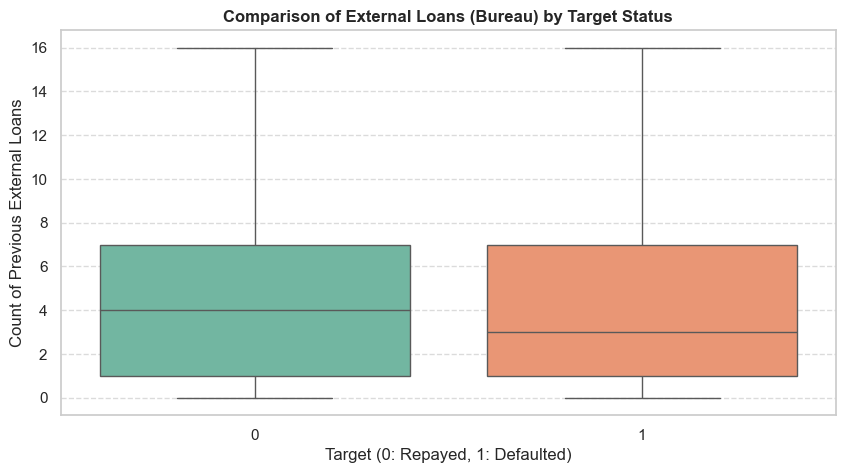

In [10]:
# --- 1. Statistical Analysis ---
# Calculate the average number of previous bureau loans grouped by target status
bureau_analysis = df_train.groupby('TARGET')['PREV_BUR_CNT'].mean()

print("📊 Mean Number of External Loans by Repayment Status:")
print(bureau_analysis)
print("-" * 60)

# --- 2. Data Visualization: Boxplot ---
# Using a boxplot to compare the distribution of external loans between groups
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='TARGET', 
    y='PREV_BUR_CNT', 
    data=df_train, 
    showfliers=False,      # Hide outliers for a cleaner view of the main distribution
    hue='TARGET',          # Explicitly define hue for consistency with seaborn standards
    palette='Set2', 
    legend=False
)

plt.title('Comparison of External Loans (Bureau) by Target Status', fontsize=12, fontweight='bold')
plt.xlabel('Target (0: Repayed, 1: Defaulted)')
plt.ylabel('Count of Previous External Loans')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# --- 1. Filter Active Credits ---
# Filter the bureau data to include only active loans
active_bureau = df_bureau[df_bureau['CREDIT_ACTIVE'] == 'Active']

# --- 2. Aggregate Total Debt per Client ---
# Calculate the total outstanding debt (AMT_CREDIT_SUM_DEBT) for each client
bureau_debt = active_bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT'].sum().reset_index(name='TOTAL_ACTIVE_DEBT')

# --- 3. Merge with the Main Training Dataset ---
# Join the debt data with the main training table
df_train = df_train.merge(bureau_debt, on='SK_ID_CURR', how='left')

# --- 4. Handle Missing Values ---
# Impute missing values with 0, assuming clients with no record have no active debt
df_train['TOTAL_ACTIVE_DEBT'] = df_train['TOTAL_ACTIVE_DEBT'].fillna(0)

# --- 5. Statistical Analysis ---
# Compare average active debt between repayed (0) and defaulted (1) clients
debt_analysis = df_train.groupby('TARGET')['TOTAL_ACTIVE_DEBT'].mean()

print("📊 Mean Total Active External Debt by Repayment Status:")
print(debt_analysis)
print("-" * 60)

📊 Mean Total Active External Debt by Repayment Status:
TARGET
0    539846.067987
1    550122.191711
Name: TOTAL_ACTIVE_DEBT, dtype: float64
------------------------------------------------------------


In [12]:
# --- 1. Load the Previous Applications Dataset ---
# Ensure DATA_DIR is already defined
prev_app_path = os.path.join(DATA_DIR, 'previous_application.csv')

try:
    df_prev = pd.read_csv(prev_app_path)
    print("✅ 'previous_application.csv' loaded successfully!")
    print(f"Dataset Dimensions: {df_prev.shape[0]} rows and {df_prev.shape[1]} columns.\n")
except FileNotFoundError:
    print(f"❌ Error: 'previous_application.csv' not found at {prev_app_path}")

# --- 2. Filter for Refused Applications ---
# Identify applications that were rejected in the past
refused_apps = df_prev[df_prev['NAME_CONTRACT_STATUS'] == 'Refused']

# --- 3. Aggregate Refusals per Client ---
# Count the number of refused applications for each unique client (SK_ID_CURR)
refused_counts = refused_apps.groupby('SK_ID_CURR').size().reset_index(name='PREV_REFUSED_CNT')

# --- 4. Merge with the Main Training Dataset ---
# Left merge ensures we retain all clients from the training set
df_train = df_train.merge(refused_counts, on='SK_ID_CURR', how='left')

# --- 5. Handle Missing Values ---
# Clients with no previous rejections are assigned a count of 0
df_train['PREV_REFUSED_CNT'] = df_train['PREV_REFUSED_CNT'].fillna(0)

# --- 6. Statistical Analysis ---
# Compare average number of past rejections between repayed (0) and defaulted (1) clients
refused_analysis = df_train.groupby('TARGET')['PREV_REFUSED_CNT'].mean()

print("📊 Mean Number of Previous Rejections by Current Repayment Status:")
print(refused_analysis)
print("-" * 60)

✅ 'previous_application.csv' loaded successfully!
Dataset Dimensions: 1413701 rows and 37 columns.

📊 Mean Number of Previous Rejections by Current Repayment Status:
TARGET
0    0.763922
1    1.176192
Name: PREV_REFUSED_CNT, dtype: float64
------------------------------------------------------------


In [13]:
# --- 1. Load Installments Payment Data ---
inst_path = os.path.join(DATA_DIR, 'installments_payments.csv')
try:
    df_inst = pd.read_csv(inst_path)
    print("✅ 'installments_payments.csv' loaded successfully!")
except FileNotFoundError:
    print(f"❌ Error: File not found at {inst_path}")

# --- 2. Feature Engineering: Calculate Days Past Due (DPD) ---
# Calculate the difference between actual payment date and installment due date
# Positive values represent delayed payments
df_inst['DPD'] = df_inst['DAYS_ENTRY_PAYMENT'] - df_inst['DAYS_INSTALMENT']

# Retain only actual delays (positive values), treat early payments as 0 delay
df_inst['DAYS_DELAYED'] = df_inst['DPD'].apply(lambda x: x if x > 0 else 0)

# Aggregate the mean delay per client
avg_delay = df_inst.groupby('SK_ID_CURR')['DAYS_DELAYED'].mean().reset_index(name='AVG_DAYS_DELAYED')

# --- 3. Merge with Main Dataset ---
df_train = df_train.merge(avg_delay, on='SK_ID_CURR', how='left')
df_train['AVG_DAYS_DELAYED'] = df_train['AVG_DAYS_DELAYED'].fillna(0)

# --- 4. Final Data Preparation and Export ---
print("🚀 Preparing the final dataset for the dashboard...")

# Selecting final features for the model/dashboard
columns_to_keep = [
    'SK_ID_CURR', 'TARGET', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 
    'DAYS_BIRTH_YEARS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
    'PREV_BUR_CNT', 'TOTAL_ACTIVE_DEBT', 'PREV_REFUSED_CNT', 'AVG_DAYS_DELAYED'
]

# Export to CSV
output_path = os.path.join(DATA_DIR, 'final_clean_credit_data.csv')
df_train[columns_to_keep].to_csv(output_path, index=False)

print(f"\n✅ Successfully saved the final clean dataset to:\n{output_path}")

✅ 'installments_payments.csv' loaded successfully!
🚀 Preparing the final dataset for the dashboard...

✅ Successfully saved the final clean dataset to:
C:\Users\pc\Documents\Downloads\home-credit-default-risk\final_clean_credit_data.csv
